# 03b Pre-Knockout Network Optimization Analysis

This notebook compares optimization objectives before knockout:

- Build a tabular surrogate dataset from Nagato training entries.
- Train the same network with `MSELoss` and `HuberLoss`.
- Plot prediction-vs-target density at three zoom levels (wide, medium, tight).

Source inspiration: www.youtube.com/watch?v=5vsLmM756LA

In [1]:
from pathlib import Path
import sys
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

root = Path.cwd()
sys.path.append(str(root / 'training'))
import nnue_lab_common as c

sns.set_theme(style='whitegrid')
device = c.device()
print('device:', device)

device: mps


In [7]:
def build_tabular_from_bin(path, max_entries=120000, stride=8):
    rows = []
    with open(path, 'rb') as f:
        i = 0
        while len(rows) < max_entries:
            raw = f.read(c.ENTRY_SIZE)
            if not raw:
                break
            if i % stride == 0:
                p = c.parse_entry(raw)
                pc = p['piece_counts']
                rows.append([
                    pc[0], pc[1], pc[2], pc[3], pc[4],
                    pc[5], pc[6], pc[7], pc[8], pc[9],
                    p['stm'], p['pieces'],
                    len(p['white_feats']), len(p['black_feats']),
                ])
            i += 1
    columns = [
        'wp', 'wn', 'wb', 'wr', 'wq',
        'bp', 'bn', 'bb', 'br', 'bq',
        'stm', 'pieces', 'wfc', 'bfc',
    ]
    X = pd.DataFrame(rows, columns=columns)
    return X

train_file = c.default_training_file()
X = build_tabular_from_bin(train_file, max_entries=120000, stride=8)

# Targets in pawns with wider spread for optimization comparison plots.
mat = (
    3.4 * (X['wq'] - X['bq'])
    + 1.9 * (X['wr'] - X['br'])
    + 1.2 * (X['wb'] - X['bb'])
    + 1.0 * (X['wn'] - X['bn'])
    + 0.23 * (X['wp'] - X['bp'])
)
phase = 0.12 * (X['pieces'] - 20)
activity = 0.05 * (X['wfc'] - X['bfc'])
stm_term = np.where(X['stm'] > 0, -0.35, 0.35)
noise = np.random.normal(0.0, 1.4, size=len(X))
y_series = np.clip(mat + phase + activity + stm_term + noise, -22, 22)
y = np.asarray(y_series, dtype=np.float32)

split = int(0.2 * len(X))
X_test_raw = X.iloc[:split].copy()
X_train_raw = X.iloc[split:].copy()
y_test = y[:split]
y_train = y[split:]

mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0).replace(0, 1.0)
X_train = ((X_train_raw - mu) / sigma).to_numpy(dtype=np.float32)
X_test = ((X_test_raw - mu) / sigma).to_numpy(dtype=np.float32)

print('train', X_train.shape, y_train.shape)
print('test ', X_test.shape, y_test.shape)
print('target std:', float(np.std(y_train)))

train (96000, 14) (96000,)
test  (24000, 14) (24000,)
target std: 1.8893612623214722


In [8]:
class TinyNet(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 32), nn.LeakyReLU(),
            nn.Linear(32, 32), nn.LeakyReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)


def fit_model(loss_name='mse', epochs=5, batch_size=1024, lr=1e-2):
    model = TinyNet(X_train.shape[1]).to(device)
    opt = optim.SGD(model.parameters(), lr=lr)
    if loss_name == 'mse':
        criterion = nn.MSELoss()
    else:
        criterion = nn.HuberLoss(delta=1.0)

    Xt = torch.tensor(X_train, device=device)
    yt = torch.tensor(y_train[:, None], device=device)

    losses = []
    model.train()
    for _ in range(epochs):
        order = torch.randperm(Xt.size(0), device=device)
        epoch_loss = 0.0
        for start in range(0, Xt.size(0), batch_size):
            idx = order[start:start + batch_size]
            xb = Xt[idx]
            yb = yt[idx]
            pred = model(xb)
            loss = criterion(pred, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * xb.size(0)
        losses.append(epoch_loss / Xt.size(0))

    model.eval()
    with torch.no_grad():
        pred = model(torch.tensor(X_test, device=device)).squeeze(1).cpu().numpy()
    return model, losses, pred

start = time.time()
m_model, m_losses, mpred = fit_model(loss_name='mse', epochs=5, batch_size=1024, lr=1e-2)
h_model, h_losses, hpred = fit_model(loss_name='huber', epochs=5, batch_size=1024, lr=1e-2)
print('mse   loss:', m_losses[-1])
print('huber loss:', h_losses[-1])
print('CPU times: total:', round(time.time() - start, 2), 's')

mse   loss: 2.071685667037964
huber loss: 0.9075440216064453
CPU times: total: 1.2 s


mse (24000,) (24000,)
huber (24000,) (24000,)


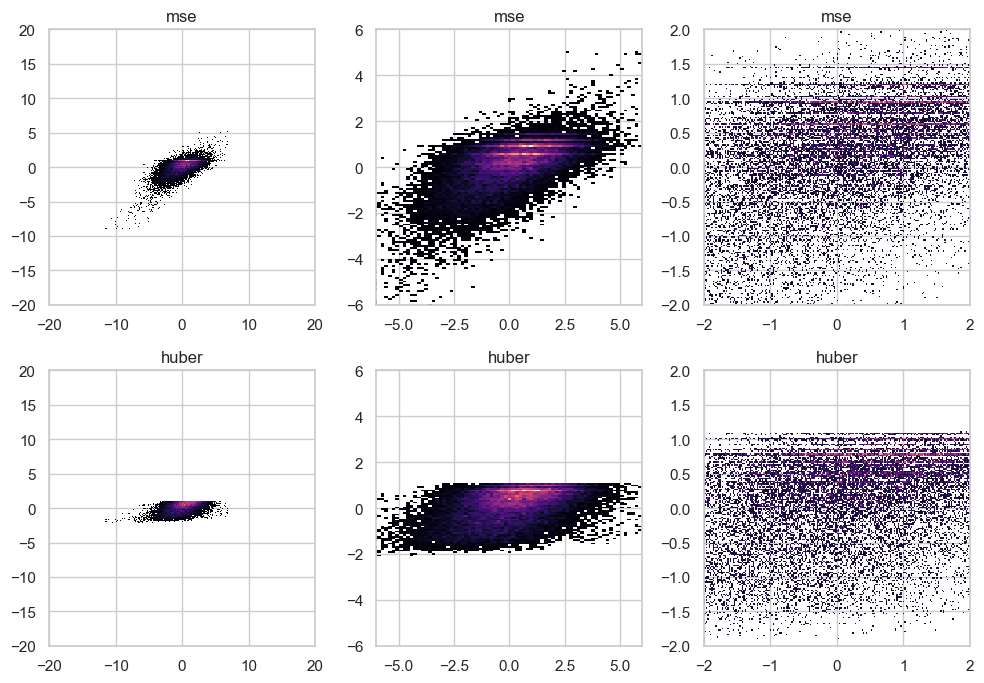

In [9]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 7))

for i, (name, pred) in enumerate([('mse', mpred), ('huber', hpred)]):
    print(name, pred.shape, y_test.shape)

    sns.histplot(x=y_test, y=pred, cmap='magma', ax=axes[i, 0])
    axes[i, 0].set_xlim(-20, 20)
    axes[i, 0].set_ylim(-20, 20)
    axes[i, 0].set_title(name)

    sns.histplot(x=y_test, y=pred, cmap='magma', ax=axes[i, 1])
    axes[i, 1].set_xlim(-6, 6)
    axes[i, 1].set_ylim(-6, 6)
    axes[i, 1].set_title(name)

    sns.histplot(x=y_test, y=pred, cmap='magma', ax=axes[i, 2], binwidth=0.02)
    axes[i, 2].set_xlim(-2, 2)
    axes[i, 2].set_ylim(-2, 2)
    axes[i, 2].set_title(name)

plt.tight_layout()
plt.show()